In [4]:
from tqdm import tqdm

from PIL import Image
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision.models import resnet18, resnet50

from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader

In [5]:
CAMERA_NAMES = [
    "/camera/inner/frontal/middle",
    "/camera/inner/frontal/far",
    "/side/left/forward",
    "/side/right/forward",
]

INTRINSICS_NAMES = [
    "/camera/inner/frontal/middle/intrinsic_params",
    "/camera/inner/frontal/far/intrinsic_params",
    "/side/left/forward/intrinsic_params",
    "/side/right/forward/intrinsic_params",
]

CAR2CAM_NAMES = [
    "/camera/inner/frontal/middle/car_to_cam",
    "/camera/inner/frontal/far/car_to_cam",
    "/side/left/forward/car_to_cam",
    "/side/right/forward/car_to_cam",
]

GRIDS_NAMES = [
    "gt_occupancy_grid",
]

In [6]:
class BaseDataset(Dataset):
    def __init__(self, data_dir: Path, mode: str = "train"):
        self.mode = mode
        self.transform = v2.Compose([
            v2.PILToTensor(),
            v2.Resize((256, 512)),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
        ])
        self.data_dir = data_dir
        self.info = pd.read_csv(data_dir / "info.csv", index_col=0)
        self.images_paths = []
        self.intrinsics_paths = []
        self.car2cam_paths = []
        if self.mode != "test":
            self.static_grids_paths = []

        for _, row in self.info.iterrows():
            self.images_paths.append([row[name] for name in CAMERA_NAMES])                
            self.intrinsics_paths.append([row[name] for name in INTRINSICS_NAMES])
            self.car2cam_paths.append([row[name] for name in CAR2CAM_NAMES])
            if self.mode != "test":
                self.static_grids_paths.append([row[name] for name in GRIDS_NAMES])


    def __len__(self):
        return len(self.info)

    def __getitem__(self, idx):
        images = torch.stack([self.transform(Image.open(self.data_dir.parent / img_path)) for img_path in self.images_paths[idx]], dim=0)
        intrinsics = np.stack([np.load(self.data_dir.parent / intr_path) for intr_path in self.intrinsics_paths[idx]], axis=0)
        car2cams = np.stack([np.load(self.data_dir.parent / car2cam_path) for car2cam_path in self.car2cam_paths[idx]], axis=0)

        if self.mode != "test":
            static_grids = np.load(self.data_dir.parent / self.static_grids_paths[idx][0]) 
            return images, intrinsics, car2cams, static_grids

        return images, intrinsics, car2cams


data_dir = Path("./data/autonomy_yandex_dataset_train/")
train_dataset = BaseDataset(data_dir, mode="train")
train_loader = DataLoader(train_dataset, batch_size=64, num_workers=8)

print(len(train_dataset), len(train_loader))

for sample in tqdm(train_loader):
    images, intrinsics, car2cams, static_grid = sample
    break

4000 63


  0%|          | 0/63 [00:12<?, ?it/s]


In [7]:
def compute_iou(preds, target, ignore_index=255, thres=0.5):
    # Preds: (B, 1, H, W) sigmoid probabilities
    # Target: (B, H, W) class indices
    
    pred_cls = (torch.sigmoid(preds) > thres).long().squeeze(1)
    
    valid_mask = (target != ignore_index)
    pred_cls = pred_cls[valid_mask]
    target = target[valid_mask]
    
    intersection = (pred_cls & target).float().sum()
    union = (pred_cls | target).float().sum()
    
    if union == 0:
        return 1.0
    return intersection / union

def calculate_iou_new(preds, targets, ignore_index=255):
    """
    Считает Macro IoU: (IoU_class_0 + IoU_class_1) / 2.
    Игнорирует пиксели со значением ignore_index (обычно 255).
    """
    # 1. Получаем бинарные предсказания (0 или 1)
    preds_sigmoid = torch.sigmoid(preds)
    preds_bin = preds_sigmoid > 0.5  # True, где предсказан класс 1
    
    # 2. Создаем маску валидных пикселей (исключаем 255)
    valid_mask = (targets != ignore_index)
    
    # --- IoU для Класса 1 (Занято / Occupied) ---
    # Intersection: Предсказано 1 И Истина 1 (в валидной зоне)
    tp_1 = (preds_bin & (targets == 1) & valid_mask).sum().float()
    # Union: Предсказано 1 ИЛИ Истина 1 (в валидной зоне)
    union_1 = ((preds_bin | (targets == 1)) & valid_mask).sum().float()
    
    iou_1 = (tp_1 + 1e-6) / (union_1 + 1e-6)
    
    # --- IoU для Класса 0 (Свободно / Free) ---
    # Intersection: Предсказано 0 И Истина 0 (в валидной зоне)
    # ~preds_bin означает "НЕ 1", то есть 0
    tp_0 = ((~preds_bin) & (targets == 0) & valid_mask).sum().float()
    # Union: Предсказано 0 ИЛИ Истина 0 (в валидной зоне)
    union_0 = (((~preds_bin) | (targets == 0)) & valid_mask).sum().float()
    
    iou_0 = (tp_0 + 1e-6) / (union_0 + 1e-6)
    
    # --- Macro Average ---
    macro_iou = (iou_1 + iou_0) / 2
    
    return macro_iou.item()



In [8]:
import math
import torch


def positionalencoding1d(d_model, length):
    """
    :param d_model: dimension of the model
    :param length: length of positions
    :return: length*d_model position matrix
    """
    if d_model % 2 != 0:
        raise ValueError("Cannot use sin/cos positional encoding with "
                         "odd dim (got dim={:d})".format(d_model))
    pe = torch.zeros(length, d_model)
    position = torch.arange(0, length).unsqueeze(1)
    div_term = torch.exp((torch.arange(0, d_model, 2, dtype=torch.float) *
                         -(math.log(10000.0) / d_model)))
    pe[:, 0::2] = torch.sin(position.float() * div_term)
    pe[:, 1::2] = torch.cos(position.float() * div_term)

    return pe


def positionalencoding2d(height, width, d_model):
    """
    :param d_model: dimension of the model
    :param height: height of the positions
    :param width: width of the positions
    :return: d_model*height*width position matrix
    """
    if d_model % 4 != 0:
        raise ValueError("Cannot use sin/cos positional encoding with "
                         "odd dimension (got dim={:d})".format(d_model))
    pe = torch.zeros(d_model, height, width)
    # Each dimension use half of d_model
    d_model = int(d_model / 2)
    div_term = torch.exp(torch.arange(0., d_model, 2) *
                         -(math.log(10000.0) / d_model))
    pos_w = torch.arange(0., width).unsqueeze(1)
    pos_h = torch.arange(0., height).unsqueeze(1)
    pe[0:d_model:2, :, :] = torch.sin(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[1:d_model:2, :, :] = torch.cos(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[d_model::2, :, :] = torch.sin(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
    pe[d_model + 1::2, :, :] = torch.cos(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)

    return pe.permute(1, 2, 0)

In [ ]:
class MultiViewBEVModelResNet(nn.Module):
    def __init__(self, bev_h=48, bev_w=32, num_classes=1, num_cameras=4):
        super().__init__()
        
        # --- Backbone ---
        resnet = resnet50(weights='DEFAULT')
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        # for p in self.encoder.parameters():
        #     p.requires_grad = False
        
        self.neck = nn.Conv2d(2048, 512, kernel_size=1)

        # --- BEV queries ---
        self.bev_h = bev_h
        self.bev_w = bev_w
        self.num_classes = num_classes
        self.num_cameras = num_cameras
        
        self.bev_queries = nn.Parameter(torch.empty(bev_h * bev_w, 512))
        nn.init.xavier_normal_(self.bev_queries)
        
        # --- Transformer ---
        self.transformer = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(512, 8, batch_first=True),
            num_layers=4,
        )
        
        # --- Positional encoding (learnable) ---
        # self.pos_encoding = nn.Parameter(torch.empty(1, num_cameras * 8 * 16, 512))  # H_feat=8, W_feat=16
        # nn.init.xavier_normal_(self.pos_encoding)

        self.register_buffer("pos_embed", positionalencoding2d(8, 16, 512))  # H_feat=8, W_feat=16
        self.register_buffer("bev_pos_embed", positionalencoding2d(self.bev_h, self.bev_w, 512) )

        self.upsample = nn.Sequential(
            # Stage 1: coarse → medium (~48x32)
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(size=(96,64), mode='bilinear', align_corners=False),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            # Stage 2: medium → finer (~94x63)
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(size=(188,126), mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            # Stage 3: finer → final (188x126)
            nn.BatchNorm2d(128),
            # nn.Upsample(size=(188,126), mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            # Final projection
            nn.BatchNorm2d(64),
            nn.Conv2d(64, num_classes, kernel_size=1)
        )

        self.intrinsics_encoder = nn.Sequential(
            nn.BatchNorm1d(12),
            nn.Linear(12, 512),
            nn.ReLU(),
            nn.Linear(512, 512)
        )

        self.car2cams_encoder = nn.Sequential(
            nn.BatchNorm1d(16),
            nn.Linear(16, 512),
            nn.ReLU(),
            nn.Linear(512, 512)
        )


    def forward(self, x, intrinsics, car2cams):
        B, N, C, H, W = x.shape
        assert N == self.num_cameras, "Number of cameras mismatch"
        
        intrinsics = self.intrinsics_encoder(intrinsics.reshape(B * N, -1).float()).reshape(B, N, -1)
        car2cams = self.car2cams_encoder(car2cams.reshape(B * N, -1).float()).reshape(B, N, -1)

        # --- Extract features from each camera ---
        x = x.view(B * N, C, H, W)
        features = self.encoder(x)  # (B*N, 512, 8,16)
        features = self.neck(features)
        _, C_feat, H_feat, W_feat = features.shape
        features = features.view(B, N, C_feat, H_feat, W_feat)
        
        # --- Flatten camera + spatial dims for transformer ---
        features = features.permute(0, 1, 3, 4, 2)  # (B, N, H_feat, W_feat, C)
        features = features + self.pos_embed[None, None]  # (B, N, H_feat, W_feat, C)
        features = features.reshape(B, N, H_feat*W_feat, C_feat)  # (B, N, H_feat*W_feat, 512)
        features = features + intrinsics.unsqueeze(2) + car2cams.unsqueeze(2) 
        features = features.reshape(B, N*H_feat*W_feat, C_feat)  # (B, seq_len, 512)

        # --- Add positional encoding ---
        # features = features + self.pos_encoding  # (B, seq_len, 512)
        
        bev_tokens = self.bev_queries.reshape(self.bev_h, self.bev_w, C_feat) + self.bev_pos_embed
        bev_tokens = bev_tokens.view(self.bev_h*self.bev_w, C_feat)
        # --- Transformer decoder ---
        bev_tokens = self.transformer(
            self.bev_queries.unsqueeze(0).repeat(B,1,1),  # (B, bev_h*bev_w, 512)
            features
        )  # (B, bev_h*bev_w, 512)
        
        # --- Reshape to coarse BEV map ---
        bev_tokens = bev_tokens.transpose(1, 2).view(B, 512, self.bev_h, self.bev_w)  # (B, 512, H_bev, W_bev)
        
        # --- Conv upsampling to final BEV ---
        bev_logits = self.upsample(bev_tokens)  # (B, num_classes, 188, 126)
        
        return bev_logits

In [ ]:
from torchvision.models import swin_t, Swin_T_Weights


class MultiViewBEVModelSwin(nn.Module):
    def __init__(self, bev_h=48, bev_w=32, num_classes=1, num_cameras=4):
        super().__init__()
        
        # --- Backbone ---
        # resnet = resnet50(weights='DEFAULT')
        # self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        swin = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(swin.children())[:-3])

        # for p in self.encoder.parameters():
        #     p.requires_grad = False
        
        self.neck = nn.Conv2d(768, 512, kernel_size=1)

        # --- BEV queries ---
        self.bev_h = bev_h
        self.bev_w = bev_w
        self.num_classes = num_classes
        self.num_cameras = num_cameras
        
        self.bev_queries = nn.Parameter(torch.empty(bev_h * bev_w, 512))
        nn.init.xavier_normal_(self.bev_queries)
        
        # --- Transformer ---
        self.transformer = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(512, 8, batch_first=True),
            num_layers=4,
        )
        
        # --- Positional encoding (learnable) ---
        # self.pos_encoding = nn.Parameter(torch.empty(1, num_cameras * 8 * 16, 512))  # H_feat=8, W_feat=16
        # nn.init.xavier_normal_(self.pos_encoding)

        self.register_buffer("pos_embed", positionalencoding2d(8, 16, 512))  # H_feat=8, W_feat=16
        self.register_buffer("bev_pos_embed", positionalencoding2d(self.bev_h, self.bev_w, 512) )

        self.upsample = nn.Sequential(
            # Stage 1: coarse → medium (~48x32)
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(size=(96,64), mode='bilinear', align_corners=False),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            # Stage 2: medium → finer (~94x63)
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(size=(188,126), mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            # Stage 3: finer → final (188x126)
            nn.BatchNorm2d(128),
            # nn.Upsample(size=(188,126), mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            # Final projection
            nn.BatchNorm2d(64),
            nn.Conv2d(64, num_classes, kernel_size=1)
        )

        self.intrinsics_encoder = nn.Sequential(
            nn.BatchNorm1d(12),
            nn.Linear(12, 512),
            nn.ReLU(),
            nn.Linear(512, 512)
        )

        self.car2cams_encoder = nn.Sequential(
            nn.BatchNorm1d(16),
            nn.Linear(16, 512),
            nn.ReLU(),
            nn.Linear(512, 512)
        )


    def forward(self, x, intrinsics, car2cams):
        B, N, C, H, W = x.shape
        assert N == self.num_cameras, "Number of cameras mismatch"
        
        intrinsics = self.intrinsics_encoder(intrinsics.reshape(B * N, -1).float()).reshape(B, N, -1)
        car2cams = self.car2cams_encoder(car2cams.reshape(B * N, -1).float()).reshape(B, N, -1)

        # --- Extract features from each camera ---
        x = x.view(B * N, C, H, W)
        features = self.encoder(x)  # (B*N, 512, 8,16)
        features = self.neck(features)
        _, C_feat, H_feat, W_feat = features.shape
        features = features.view(B, N, C_feat, H_feat, W_feat)
        
        # --- Flatten camera + spatial dims for transformer ---
        features = features.permute(0, 1, 3, 4, 2)  # (B, N, H_feat, W_feat, C)
        features = features + self.pos_embed[None, None]  # (B, N, H_feat, W_feat, C)
        features = features.reshape(B, N, H_feat*W_feat, C_feat)  # (B, N, H_feat*W_feat, 512)
        features = features + intrinsics.unsqueeze(2) + car2cams.unsqueeze(2) 
        features = features.reshape(B, N*H_feat*W_feat, C_feat)  # (B, seq_len, 512)

        # --- Add positional encoding ---
        # features = features + self.pos_encoding  # (B, seq_len, 512)
        
        bev_tokens = self.bev_queries.reshape(self.bev_h, self.bev_w, C_feat) + self.bev_pos_embed
        bev_tokens = bev_tokens.view(self.bev_h*self.bev_w, C_feat)
        # --- Transformer decoder ---
        bev_tokens = self.transformer(
            self.bev_queries.unsqueeze(0).repeat(B,1,1),  # (B, bev_h*bev_w, 512)
            features
        )  # (B, bev_h*bev_w, 512)
        
        # --- Reshape to coarse BEV map ---
        bev_tokens = bev_tokens.transpose(1, 2).view(B, 512, self.bev_h, self.bev_w)  # (B, 512, H_bev, W_bev)
        
        # --- Conv upsampling to final BEV ---
        bev_logits = self.upsample(bev_tokens)  # (B, num_classes, 188, 126)
        
        return bev_logits


In [ ]:
device = 'cuda:0'

model = MultiViewBEVModelSwin().to(device) # MultiViewBEVModelResNet
optimizer = AdamW(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

sum([p.numel() for p in model.parameters()])

50555955

In [ ]:
train_dataset = BaseDataset(data_dir=Path("./data/autonomy_yandex_dataset_train/"), mode="train")
val_dataset = BaseDataset(data_dir=Path("./data/autonomy_yandex_dataset_val/"), mode="val")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=8, num_workers=8)

losses_train = list()
lolles_val = list()
iou_train = list()
iou_val = list()

best_val = 0

for epoch in range(100):
    model.train()

    iou_list_epoch = []
    pbar = tqdm(train_loader)
    for i, batch in enumerate(pbar):
        optimizer.zero_grad()
        images, intrinsics, car2cams, gt = batch
        images, intrinsics, car2cams, gt = images.to(device), intrinsics.to(device), car2cams.to(device), gt.to(device)

        loss_mask = (gt != 255)
    
        preds = model.forward(images, intrinsics, car2cams)
        
        loss = criterion(preds[loss_mask], gt[loss_mask].float())
        losses_train.append(loss.item())
        loss.backward()
        optimizer.step()
        # if i == 200:
        #     break

        iou_list_epoch.append(calculate_iou_new(preds, gt))
        pbar.set_postfix({'Loss': loss.item(), 'Train IOU': iou_list_epoch[-1]})
    iou_train.append(np.mean(iou_list_epoch))


    iou_list_epoch = []
    with torch.no_grad():
        model.eval()

        for i, batch in enumerate(tqdm(val_loader)):
            images, intrinsics, car2cams, gt = batch
            images, intrinsics, car2cams, gt = images.to(device), intrinsics.to(device), car2cams.to(device), gt.to(device)

            loss_mask = (gt != 255)

            preds = model.forward(images, intrinsics, car2cams)

            lolles_val.append(criterion(preds[loss_mask], gt[loss_mask].float()).item())
            iou_list_epoch.append(calculate_iou_new(preds, gt))

    iou_val.append(np.mean(iou_list_epoch))

    if best_val < iou_val[-1]:
        best_val = iou_val[-1]
        torch.save(model.state_dict(), f'checkpoints/{epoch}_{best_val}.pth')


    print(f"Epoch: {epoch}, IOU: {iou_val[-1]}")

100%|██████████| 125/125 [00:25<00:00,  4.87it/s]


Epoch: 0, IOU: 0.42611992728710174


100%|██████████| 125/125 [00:25<00:00,  4.84it/s]


Epoch: 1, IOU: 0.49747960925102236


100%|██████████| 125/125 [00:25<00:00,  4.83it/s]


...

100%|██████████| 125/125 [00:25<00:00,  4.90it/s]


Epoch: 31, IOU: 0.567016120672226


100%|██████████| 125/125 [00:25<00:00,  4.82it/s]


Epoch: 32, IOU: 0.5550074093341827


  0%|          | 0/500 [00:00<?, ?it/s]

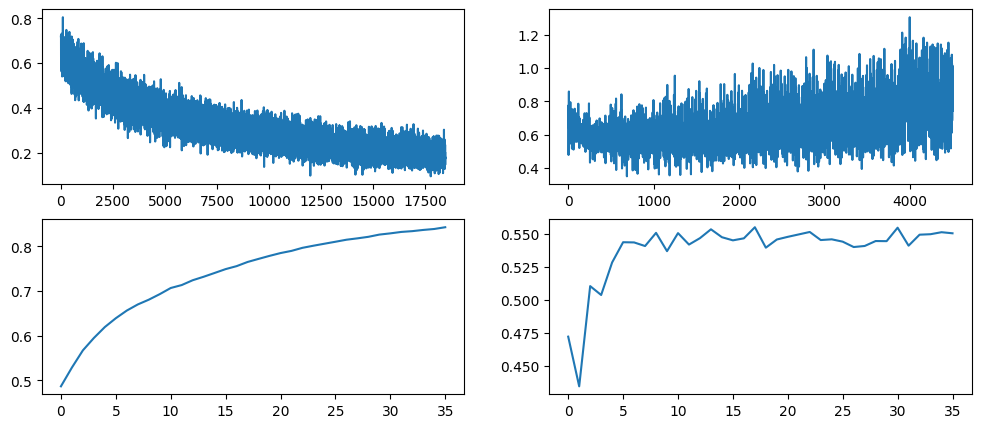

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))

axes[0, 0].plot(losses_train)
axes[1, 0].plot(iou_train)

axes[0, 1].plot(lolles_val)
axes[1, 1].plot(iou_val)


In [107]:
torch.save(model.state_dict(), 'checkpoint_4.pth')

In [81]:
iou_list = []
with torch.no_grad():
    for i, batch in enumerate(tqdm(train_loader)):
        images, intrinsics, car2cams, gt = batch
        images, intrinsics, car2cams, gt = images.to(device), intrinsics.to(device), car2cams.to(device), gt.to(device)

        loss_mask = (gt != 255)
        
        preds = model.forward(images, intrinsics, car2cams)

        iou_list.append(compute_iou(preds, gt[:, 0]).item())


100%|██████████| 500/500 [00:35<00:00, 14.06it/s]


In [82]:
np.mean(iou_list)

np.float64(0.6949661003947258)

In [84]:
iou_list_2 = []

with torch.no_grad():
    for thr in np.linspace(0.1, 1, 10):
        iou_list = []
        for i, batch in enumerate(tqdm(val_loader)):
            images, intrinsics, car2cams, gt = batch
            images, intrinsics, car2cams, gt = images.to(device), intrinsics.to(device), car2cams.to(device), gt.to(device)

            loss_mask = (gt != 255)
            
            preds = model.forward(images, intrinsics, car2cams)

            iou_list.append(compute_iou(preds, gt[:, 0], thres=thr).item())

        iou_list_2.append(np.mean(iou_list))

100%|██████████| 125/125 [00:10<00:00, 12.19it/s]


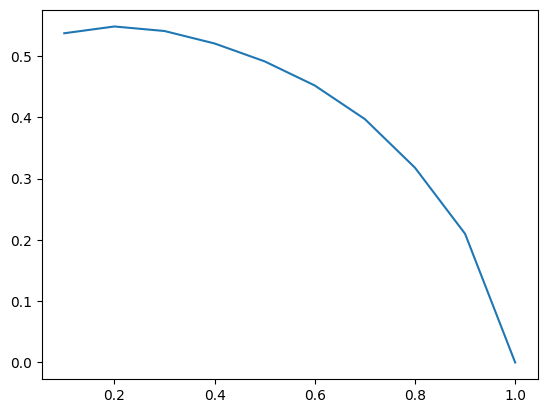

In [85]:
plt.plot(np.linspace(0.1, 1, 10), iou_list_2)

In [103]:
TEST_DIR =  "autonomy_yandex_dataset_test"

def generate_submission(model_path):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    test_ds = BaseDataset(data_dir=Path("./data/autonomy_yandex_dataset_test/"), mode="test")
    test_loader = DataLoader(test_ds, batch_size=1, num_workers=8)
    
    test_info = pd.read_csv("./data/autonomy_yandex_dataset_test/info.csv", index_col=0)
    
    # model = MultiViewBEVModel().to(device)
    # model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    SUB_DIR = Path("submission/predicted_static_grids")
    SUB_DIR.mkdir(parents=True, exist_ok=True)
    
    with torch.no_grad():
        for i, (images, intrinsics, car2cams) in enumerate(tqdm(test_loader, desc="Inference")):
            images, intrinsics, car2cams = images.to(device), intrinsics.to(device), car2cams.to(device)
            
            preds = model.forward(images, intrinsics, car2cams)
            probs = torch.sigmoid(preds)
            
            # Thresholding
            pred_grid = (probs > 0.5).int().cpu().numpy()
            pred_grid = pred_grid.squeeze() # (188, 126)
            
            # Get path from info
            orig_rel_path = test_info.iloc[i]["predicted_occupancy_grid"]
            filename = Path(orig_rel_path).name
            save_path = SUB_DIR / filename
            
            np.save(save_path, pred_grid)
            
    print("Inference complete. Zip the 'submission' folder.")

generate_submission(None)

Inference: 100%|██████████| 2000/2000 [00:26<00:00, 75.51it/s]

Inference complete. Zip the 'submission' folder.


In [104]:
import shutil

# Zip entire folder
shutil.make_archive('submission', 'zip', 'submission')


'/app/submission.zip'

In [99]:
import os 

len(os.listdir('submission/predicted_static_grids'))

2000

Loading Info CSV...
Visualizing sample index: 63


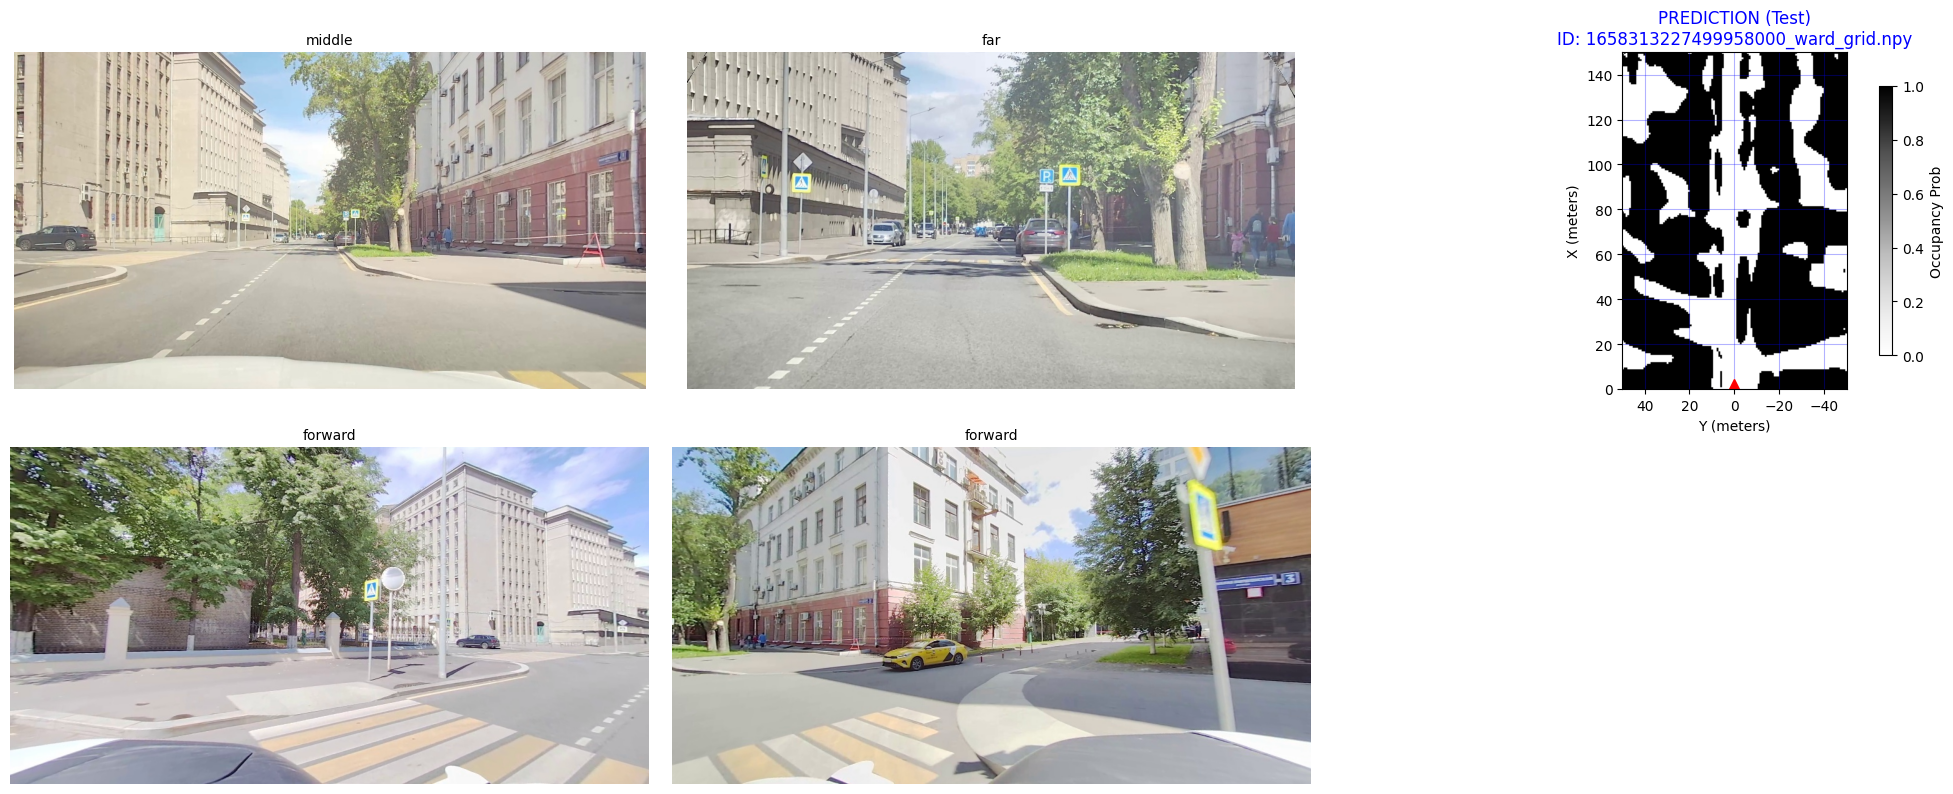

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os
from pathlib import Path

# --- НАСТРОЙКИ ПУТЕЙ ---
DATA_ROOT = "./data"
PREDICTIONS_DIR = "submission/predicted_static_grids/"

# Константы (из вашего кода)

CAMERA_NAMES = [
    "/camera/inner/frontal/middle",
    "/camera/inner/frontal/far",
    "/side/left/forward",
    "/side/right/forward",
]

def read_images(row):
    """Читает изображения, добавляя корневой путь"""
    images = []
    for camera_name in CAMERA_NAMES:
        # Формируем полный путь: aidao2025/autonomy_yandex_dataset_test/images/...
        full_path = os.path.join(DATA_ROOT, row[camera_name])
        
        if os.path.exists(full_path):
            img = np.asarray(Image.open(full_path))
            # Нормализация (как у вас в примере)
            images.append(img.astype(np.float32) / 255.0)
        else:
            print(f"Warning: Image not found {full_path}")
            images.append(np.zeros((100, 100, 3))) # Черный квадрат заглушка
            
    return images

def plot_test_prediction(data_info, sample_idx: int = 10):
    """
    Визуализирует изображения с камер и ПРЕДСКАЗАННУЮ карту для теста.
    """
    row = data_info.iloc[sample_idx]

    # 1. Формируем путь к предсказанию
    # Формат имени файла: <log_time>_<rover>_grid.npy
    pred_filename = f"{row['header_ts']}_{row['rover']}_grid.npy"
    pred_path = os.path.join(PREDICTIONS_DIR, pred_filename)

    # 2. Загружаем предсказание
    if os.path.exists(pred_path):
        pred_grid = np.load(pred_path).squeeze()
    else:
        print(f"Prediction file not found: {pred_path}")
        # Создаем пустую карту, чтобы код не упал
        pred_grid = np.zeros((188, 126))

    # 3. Загружаем картинки
    camera_images = read_images(row)

    # --- ВИЗУАЛИЗАЦИЯ ---
    fig = plt.figure(figsize=(20, 12))

    # Расположение камер (как в вашем примере: 1, 2, 4, 5)
    places = [1, 2, 4, 5]
    
    for i, image in enumerate(camera_images):
        ax = fig.add_subplot(3, 3, places[i])
        cam_title = CAMERA_NAMES[i].split('/')[-1] # короткое имя камеры
        ax.imshow(image)
        ax.set_title(cam_title, fontsize=10)
        ax.axis('off')

    # Параметры отображения карты
    # extent = [-50, 50, 0, 150] # [left, right, bottom, top] - из вашего примера
    # Однако, согласно описанию задачи (188px = 150m, 126px = 100m, машинка в центре по ширине)
    # BEV обычно рисуется так:
    extent = [-50, 50, 0, 150] 

    # Отрисовка ПРЕДСКАЗАНИЯ (в позиции 3, где был GT)
    ax_map = fig.add_subplot(3, 3, 3) # Можно сделать fig.add_subplot(1, 3, 3) чтобы было на всю высоту
    
    # Для предсказания лучше использовать черно-белую гамму или простую
    # 0 = Свободно, 1 = Занято
    # vmin=0, vmax=1
    im_map = ax_map.imshow(pred_grid, cmap='Greys', extent=extent, origin='lower', vmin=0, vmax=1)
    
    ax_map.set_title(f'PREDICTION (Test)\nID: {pred_filename}', fontsize=12, color='blue')
    
    # У вас в коде было invert_xaxis(), это зависит от того, как сохранены данные.
    # Если на картинке "лево" становится "право", раскомментируйте строчку ниже:
    ax_map.invert_xaxis() 
    
    ax_map.set_xlabel('Y (meters)')
    ax_map.set_ylabel('X (meters)')
    
    # Рисуем эго-машину
    ax_map.plot(0, 0, marker='^', color='red', markersize=15, label='Ego Car')
    
    plt.colorbar(im_map, ax=ax_map, shrink=0.8, label='Occupancy Prob')
    ax_map.grid(True, alpha=0.3, color='blue')

    plt.tight_layout()
    plt.show()

# --- ЗАПУСК ---

# Путь к info.csv
csv_path = os.path.join(DATA_ROOT, "autonomy_yandex_dataset_test/info.csv")



if os.path.exists(csv_path):
    print("Loading Info CSV...")
    data_info = pd.read_csv(csv_path) # index_col=0 удален, так как иногда индексы сбиваются, лучше дефолтный
    
    # Ищем интересный пример (где timestamp совпадает с тем, что мы обсуждали ранее)
    # Например, индекс 12 или по поиску
    sample_idx = 63
    
    print(f"Visualizing sample index: {sample_idx}")
    plot_test_prediction(data_info, sample_idx)
else:
    print(f"Error: CSV not found at {csv_path}")
